In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/olmo/scripts') # Add the parent directory to sys.path

import pandas as pd
import numpy as np

from utils import DATA_DIR
from dataloader import get_nd_array, get_slice

from download.weka import pull_predictions_from_weka

In [3]:
# pull_predictions_from_weka("aws")

In [4]:
df = pd.read_parquet(f'{DATA_DIR}/all_aws_predictions.parquet')

In [179]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
STEPS  = df.index.get_level_values('step').unique().to_list()

TASKS = [t for t in TASKS if 'mmlu' not in t]

print(MODELS)
print(TASKS)
print(MIXES)
# print(STEPS)

['peteish13-highlr', 'peteish7', 'phi-1_5', 'peteish-moreeval-1B-2xC', 'peteish-moreeval-190M-2xC', 'peteish-moreeval-rerun-370M-1xC', 'peteish-moreeval-rerun-190M-1xC', 'peteish-moreeval-760M-0.5xC', 'peteish-moreeval-1B-5xC', 'falcon_and_cc_eli5_oh_top10p-1B-5xC', 'fineweb_edu_dedup-1B-5xC', 'falcon_and_cc_og_eli5_oh_top10p-1B-5xC', 'falcon_and_cc-1B-5xC', 'no_flan-1B-5xC', 'prox_fineweb_pro-1B-5xC', 'falcon_and_cc_eli5_oh_top20p-1B-5xC', 'baseline-1B-5xC', 'falcon_and_cc_tulu_qc_top10-1B-5xC', 'no_math_no_code-1B-5xC', 'c4-1B-5xC', 'redpajama-1B-5xC', 'no_code-1B-5xC', 'no_reddit-1B-5xC', 'falcon-1B-5xC', 'peteish-moreeval-rerun-760M-1xC', 'peteish-moreeval-370M-2xC', 'DCLM-baseline-1B-5xC', 'dolma17-25p-DCLM-baseline-75p-1B-5xC', 'dolma17-50p-DCLM-baseline-50p-1B-5xC', 'dolma-v1-6-and-sources-baseline-1B-5xC', 'dolma17-75p-DCLM-baseline-25p-1B-5xC', 'peteish-moreeval-760M-10xC', 'peteish-moreeval-3B-10xC', 'peteish-moreeval-rerun-3B-1xC', 'peteish-moreeval-rerun-1B-1xC', 'peteish-m

In [6]:
# models, scores = get_nd_array(df, 'model', 'acc_per_char', task='arc_challenge:distractors')
# models, scores = get_nd_array(df, ['model', 'mix'], 'acc_per_char', task='arc_challenge:distractors')

### Measure 1: Predictability (Rel Error @ 7B)

In [57]:
LADDER_MODELS = [model for model in MODELS if 'peteish-moreeval' in model]

In [212]:
from olmo.scaling.scaling_laws.utils import get_final_configs, get_step2_data_by_name, get_task_sets
from scaling.step2 import main as step2_main
from scaling.step2 import fit_step2, predict_step2, plot_step2

os.chdir('/Users/dhei/ai2/new-evals/olmo-repos/olmo')

config_path = "scripts/scaling/final.json"
# config_path = "scripts/scaling/final_7b_only.json"

configs = get_final_configs(config_path)
task_names = get_task_sets(["v2_main_variance"])

data_by_name = get_step2_data_by_name(
    configs,
    'arc_easy_test_5shot',
    x_metric='rc_bpb',
    y_metric='rc_acc',
    moving_avg=5,
    skip_perc=0.1,
)

coefficients, cov = fit_step2(data_by_name, 'arc_easy_test_5shot', 'rc_acc', use_log_sigmoid=False)

(
    predicted_data_by_name, plotted_predicted_data,
    (y, y_pred, rel_error, delta_error), all_rel_errors,
) = predict_step2(
    configs, data_by_name, coefficients, cov, y_metric='rc_acc', use_log_sigmoid=False
)

print(rel_error)

-0.06003510757433322


In [48]:
# labeled by size
data_by_name['1B'].keys()

# xs - task loss
# ys - task accuracy
# ds - tokens (step 1) -- can take from wandb logs processed by olmo script (for Ian's project I'd can hook up the same script to extract wandb info)
# ns - params (step 1) -- can extract from config file
# ls - labels (step 1)
# mode - train/eval

dict_keys(['xs', 'ys', 'ds', 'ns', 'ls', 'mode'])

In [ ]:
from download.preprocess import SIZE_PREFIXES, str_find
from collections import defaultdict

xs = []
ys = []

# task_name = 'arc_easy:enlarge'
# task_name = 'arc_easy:distractors'
# task_name = 'arc_easy:para'
task_name = 'arc_challenge'

# task_name = 'csqa'

data_by_name = defaultdict(dict)

for model in LADDER_MODELS + ['peteish7']:
# for model in MODELS:
    # Use ladder models only
    if 'peteish-moreeval' in model:
        size = str_find(SIZE_PREFIXES, model)
        if size is not None: size = size.replace('-', '')
        mode = 'train'
    else:
        mode = 'eval'
        size = '7B-4T'

    if size == '3B': continue

    # # Use all Models
    # if 'peteish13-highlr' in model:
    #     mode = 'eval'
    #     # size = '7B-4T'
    #     size = '13B-5T'
    # else:
    #     size = str_find(SIZE_PREFIXES, model)
    #     if size is not None: 
    #         size = size.replace('-', '')
    #     if size is None or size == '3B':
    #         size = '1B'
    #     mode = 'train'

    # _slice = get_slice(df, model=model, task=task_name)
    _, corr = get_nd_array(df, 'model', 'correct_choice', model=model, task=task_name, step='max')
    _, logits_per_char = get_nd_array(df, 'model', 'logits_per_char', model=model, task=task_name, step='max')
    _, acc = get_nd_array(df, 'model', 'acc_per_char', model=model, task=task_name, step='max')

    if mode == 'eval': 
        print(corr)
        print(acc)
        print(size)

    if len(corr) == 0: continue
    
    # print(acc.shape, acc.mean(axis=1), model)

    correct_logits_per_char = np.empty_like(corr, dtype=np.int64)
    rows, cols = corr.shape
    for i in range(rows):
        for j in range(cols):
            correct_logits_per_char[i, j] = logits_per_char[i, j][corr[i, j]]

    # print(model, acc.shape)
    correct_logits_per_char = -correct_logits_per_char.mean(axis=1)
    acc = acc.mean(axis=1)

    # log probs per char
    # xs += [logits[choice] for choice, logits in zip(_slice['correct_choice'], _slice['logits_per_char'])]
    # ys += _slice['acc_per_char'].to_list()

    if 'xs' not in data_by_name[size]: data_by_name[size]['xs'] = []
    if 'ys' not in data_by_name[size]: data_by_name[size]['ys'] = []

    data_by_name[size]['xs'] += [correct_logits_per_char.item()]
    data_by_name[size]['ys'] += [acc.item()]
    data_by_name[size]['mode'] = mode

[[3 2 2 ... 0 3 0]]
[[1 1 1 ... 1 0 1]]
7B-4T


0.1706045522536694


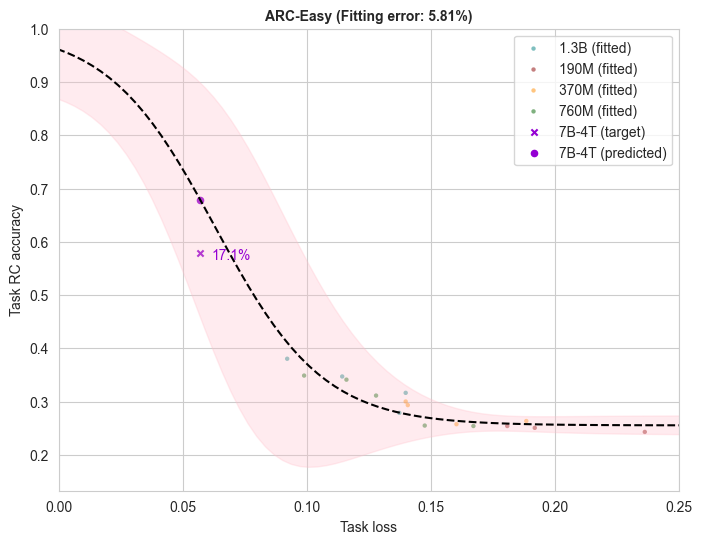

In [224]:
import matplotlib.pyplot as plt

coefficients, cov = fit_step2(data_by_name, 'arc_easy_test_5shot', None, use_log_sigmoid=False)

(
    predicted_data_by_name, plotted_predicted_data,
    (y, y_pred, rel_error, delta_error), all_rel_errors,
) = predict_step2(
    configs, data_by_name, coefficients, cov, y_metric='rc_acc', use_log_sigmoid=False
)

num_rows, num_cols = 1, 1
# fig, axes = plt.subplots(num_rows, num_cols, figsize=(2.75 * num_cols, 2.5 * num_rows), squeeze=False)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 6), squeeze=False)
ax = axes[0, 0]

plot_step2(
    configs, data_by_name, predicted_data_by_name, plotted_predicted_data, 'arc_easy_test_5shot', None, 'rc_bpb', 'rc_acc',
    coefficients, cov, use_log_sigmoid=False, ax=ax,
)

ax.set_xlim(0, 0.25)

print(rel_error)

In [36]:
# you just need to reproduce "data_by_name" !!

# ladder_models = [m for m in models if 'peteish-moreeval' in m]

# Input: [parameters, tokens, task loss, task accuracy, target model]
# Output: [rel error, abs error]

# TODO:
    # Add C4 loss from wandb logs to ladder models
    # Add BPB loss to oe-eval

0.8717171669006347

### Measure 2: Seperability (% sig @ 1B)

In [7]:
from stats import compute_significance
from utils.constants_models import MODEL_LIST_MIXES

MODEL_LIST_MIXES = [model.split('/')[-1] for model in MODEL_LIST_MIXES]

In [8]:
tasks = TASKS # ['arc_easy']

sig_results, _ = compute_significance(df, MODEL_LIST_MIXES, 'acc_per_char', tasks=tasks)
# sig_results, fig = compute_significance(df, MODEL_LIST_MIXES, 'acc_per_char', tasks=tasks, do_plot=True)

Computing pairwise comparisons:  55%|█████▍    | 12/22 [00:02<00:02,  4.94it/s]

Computing pairwise comparisons:  73%|███████▎  | 16/22 [00:03<00:01,  3.61it/s]

Computing pairwise comparisons: 100%|██████████| 22/22 [00:04<00:00,  4.53it/s]


In [9]:
from table import display_task_variants

print('% of significant comparisons for 1B-5xC models on 20 data mixes:')
display_task_variants(sig_results, key='1B')

% of significant comparisons for 1B-5xC models on 20 data mixes:


/Users/dhei/ai2/new-evals/analysis/table.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results = results.fillna('--')


Variant,default rc,distractors,enlarge,para
Task,,,,
arc_easy,90.0%,91.3% (+1.3%),92.6% (+2.6%),85.5% (-4.5%)
hellaswag,87.9%,--,--,80.3% (-7.6%)
csqa,79.7%,--,--,52.6% (-27.1%)
arc_challenge,75.3%,76.8% (+1.6%),89.5% (+14.2%),77.6% (+2.4%)
boolq,71.1%,--,--,79.7% (+8.7%)
socialiqa,56.6%,--,--,44.5% (-12.1%)
openbookqa,51.6%,--,--,53.9% (+2.4%)
piqa,34.2%,--,--,31.1% (-3.2%)
winogrande,24.7%,--,--,26.3% (+1.6%)


### Measure 3: Smoothness (Total Variation @ 1B)

In [10]:
from stats import calc_total_variation

In [11]:
tv_results = pd.DataFrame(index=['total_variation'], columns=TASKS)

for task in TASKS:
    models, scores = get_nd_array(df, 'step', 'acc_per_char', model='peteish-moreeval-1B-5xC', task=task) # (step, instance)

    if len(scores) <= 1: continue

    acc = scores.mean(axis=1) # (step)
    
    tv_results.loc['total_variation', task] = calc_total_variation(acc, improvement=True) * 100

In [12]:
print(f'TV-I for {scores.shape[0]} intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):')
display_task_variants(tv_results, key='total_variation', as_prct=False, inverse=True, ascending=True)

TV-I for 164 intermediate checkpoints on 1B 5xC peteish ladder (OLMoE mix):


/Users/dhei/ai2/new-evals/analysis/table.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results = results.fillna('--')


Variant,default rc,distractors,enlarge,para
Task,,,,
hellaswag,0.17,--,--,0.18 (+0.01)
piqa,0.37,--,--,0.38 (+0.01)
socialiqa,0.50,--,--,0.57 (+0.07)
arc_easy,0.53,0.59 (+0.06),0.58 (+0.05),0.43 (-0.10)
csqa,0.56,--,--,0.67 (+0.11)
winogrande,0.62,--,--,0.67 (+0.05)
arc_challenge,0.67,0.67 (+0.00),0.53 (-0.15),0.72 (+0.05)
openbookqa,0.93,--,--,1.03 (+0.10)
boolq,3.56,--,--,1.13 (-2.43)
